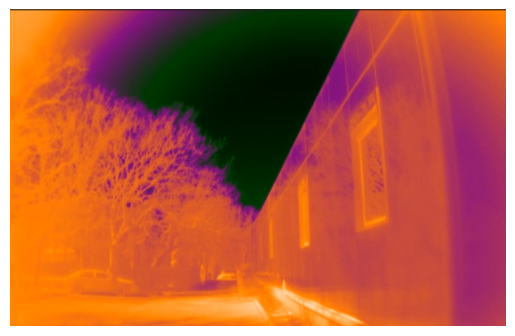

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

img_path = "images/thermal_image_1.png"
img = cv2.imread(img_path)
if img is None:
    print("Problem finding image")

def _convert_from_bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def _convert_from_bgr_to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
plt.imshow(_convert_from_bgr_to_rgb(img), vmin=0, vmax=255)
plt.axis("off")
plt.show()

(256, 1)


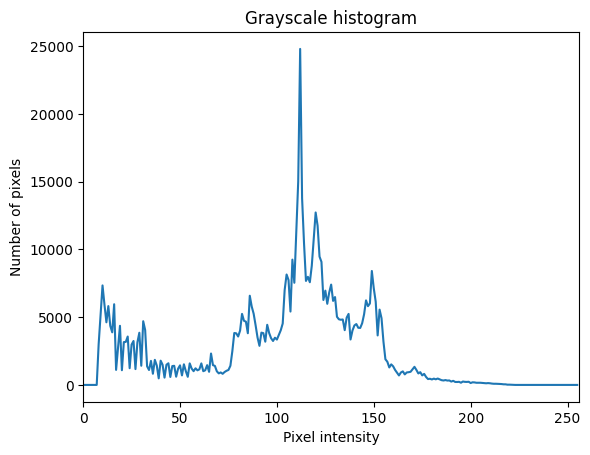

In [2]:
gray_image = _convert_from_bgr_to_gray(img)
save_path = "outputs/histograms/"
hist = cv2.calcHist(
    [gray_image],      # image
    [0],         # channel
    None,        # no mask
    [256],       # number of bins
    [0, 256]     # intensity range
)

print(hist.shape)

plt.figure()
plt.title("Grayscale histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.plot(hist)
plt.xlim([0, 256])
plt.savefig(save_path + "grayscale_histogram.png")
plt.show()

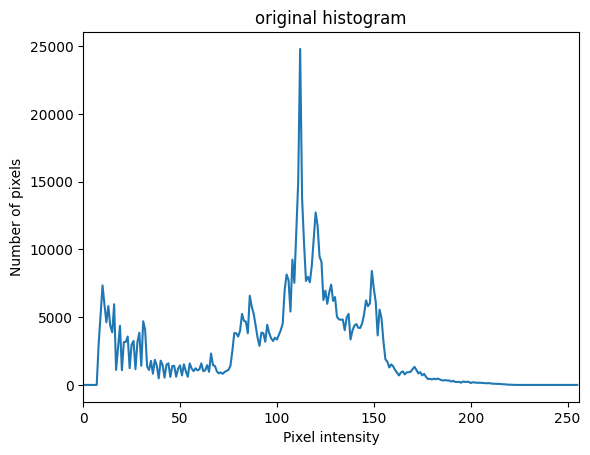

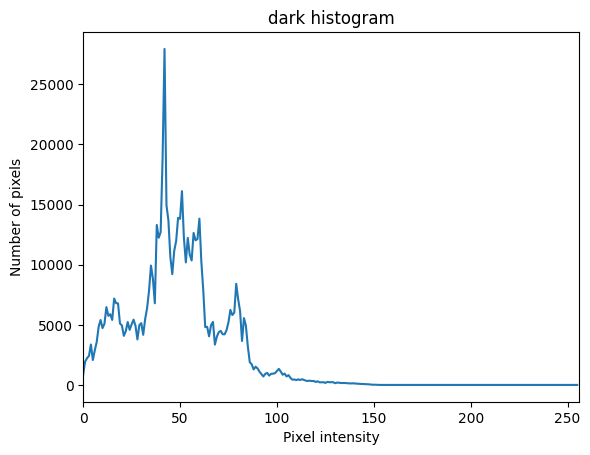

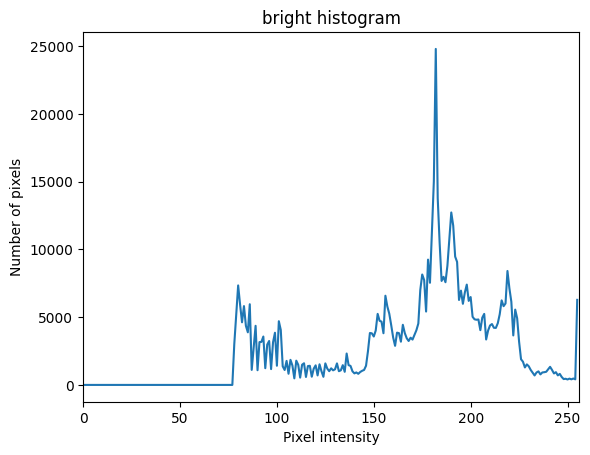

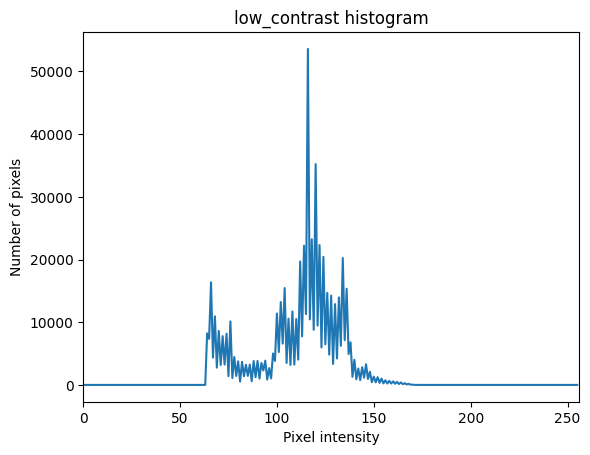

In [3]:
# interpreting histogram
dark = cv2.convertScaleAbs(gray_image, alpha=1.0, beta=-70)
bright = cv2.convertScaleAbs(gray_image, alpha=1.0, beta=70)
low_contrast = cv2.convertScaleAbs(gray_image, alpha=0.5, beta=60)

images = {
    "original": gray_image,
    "dark": dark,
    "bright": bright,
    "low_contrast": low_contrast,
}

for name, image in images.items():
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])

    plt.figure()
    plt.title(f"{name} histogram")
    plt.xlabel("Pixel intensity")
    plt.ylabel("Number of pixels")
    plt.plot(hist)
    plt.xlim([0, 256])
    plt.savefig(save_path + f"{name}_histogram.png")
    plt.show()

    cv2.imwrite(save_path + f"{name}.jpg", image)

In [4]:
# Calculate simple brightness and contrast metrics

# low mean     → darker image
# high mean    → brighter image
# low std      → low contrast
# high std     → high contrast

mean_brightness = gray_image.mean()
contrast_std = gray_image.std()

print("Mean brightness:", mean_brightness)
print("Contrast std:", contrast_std)

Mean brightness: 101.4152585765489
Contrast std: 43.38499934109052


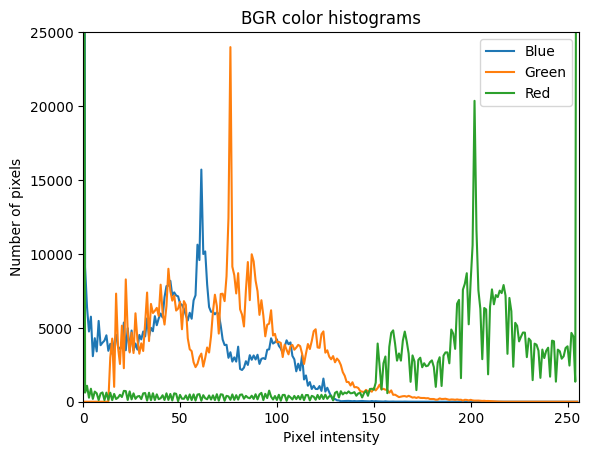

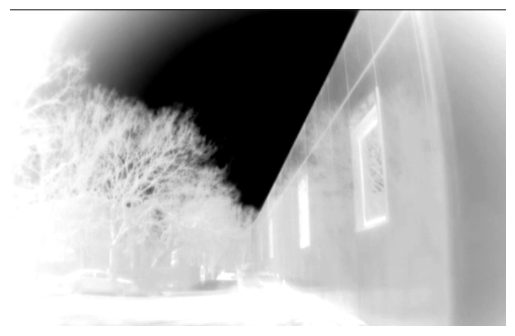

In [5]:
# Color histograms

channels = cv2.split(img)
channel_names = ["Blue", "Green", "Red"]

plt.figure()
plt.title("BGR color histograms")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")

for channel, name in zip(channels, channel_names):
    hist = cv2.calcHist([channel], [0], None, [256], [0, 256])
    plt.plot(hist, label=name)

plt.xlim([0, 256])
plt.ylim([0, 25000])
plt.legend()
plt.savefig(save_path + "color_histograms.png")
plt.show()

plt.imshow(channels[2], cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

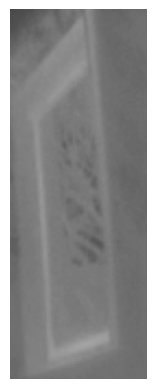

In [6]:
# histogram with a mask
x1, y1 = (700, 190)
x2, y2 = (800, 460)

roi = gray_image[y1:y2, x1:x2]

plt.imshow(roi, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

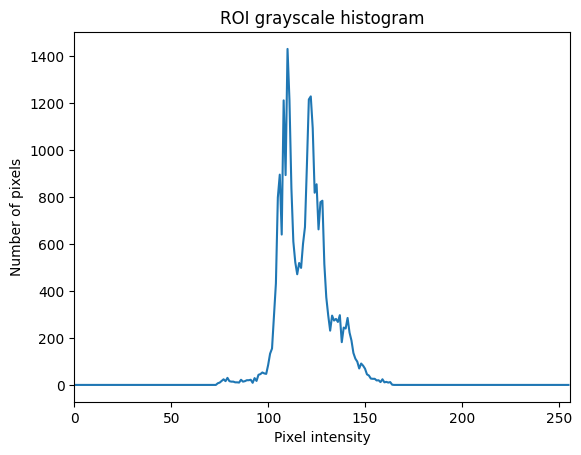

In [7]:
hist = cv2.calcHist(
    [roi],
    [0],
    None,
    [256],
    [0, 256]
)

plt.figure()
plt.title("ROI grayscale histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.plot(hist)
plt.xlim([0, 256])
plt.savefig(save_path + "roi_histogram.png")
plt.show()

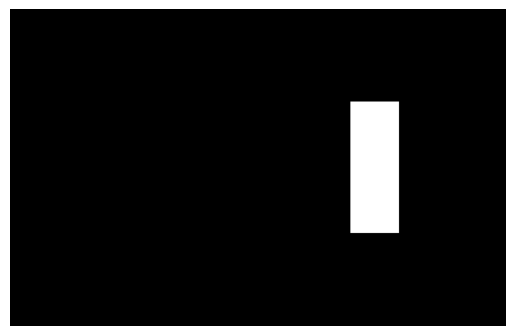

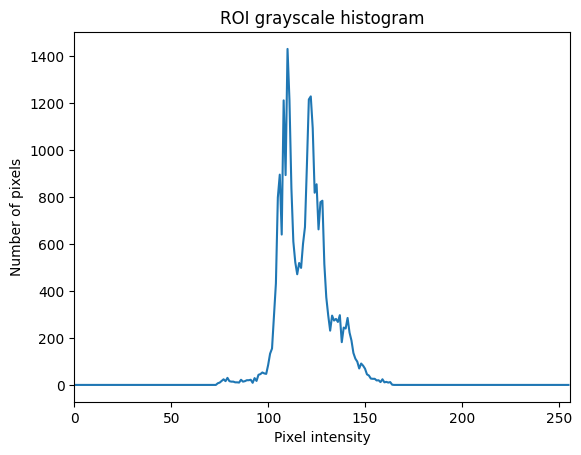

In [10]:
# using makk in function
mask = np.zeros(gray_image.shape, dtype=np.uint8)
mask[y1:y2, x1:x2] = 255

plt.imshow(mask, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

hist2 = cv2.calcHist([gray_image], [0], mask, [256], [0, 256]) #here he whole image is used
plt.figure()
plt.title("ROI grayscale histogram")
plt.xlabel("Pixel intensity")
plt.ylabel("Number of pixels")
plt.plot(hist2)
plt.xlim([0, 256])
plt.show()

Original


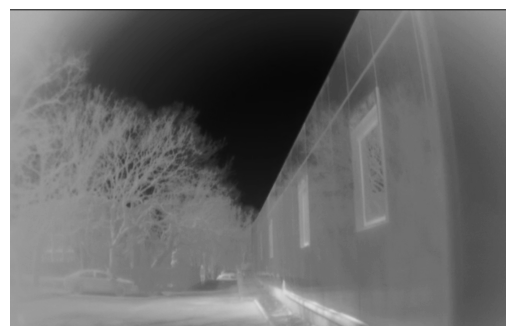

Equalized


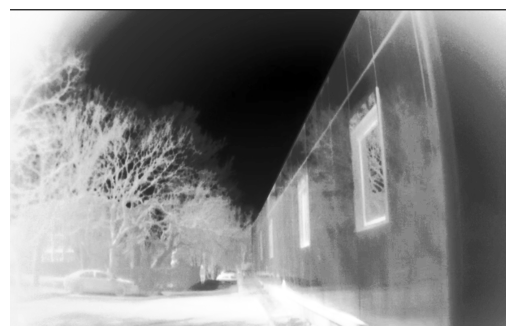

In [12]:
# Histogram equalization
equalized = cv2.equalizeHist(gray_image)

cv2.imwrite(save_path + "equalized.jpg", equalized)

print("Original")
plt.imshow(gray_image, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

print("Equalized")
plt.imshow(equalized, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

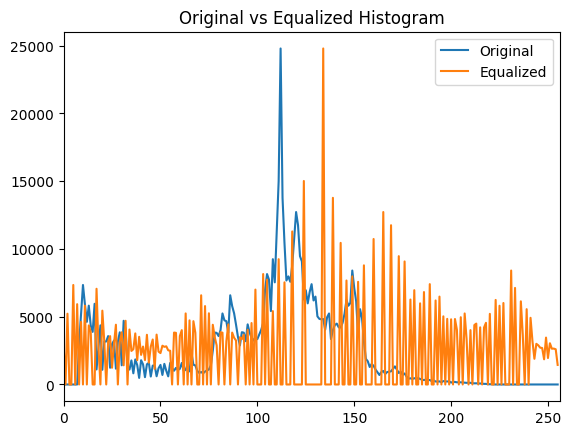

In [13]:
# histogrqm comparisson

hist_original = cv2.calcHist([gray_image], [0], None, [256], [0, 256])
hist_equalized = cv2.calcHist([equalized], [0], None, [256], [0, 256])

plt.figure()
plt.title("Original vs Equalized Histogram")
plt.plot(hist_original, label="Original")
plt.plot(hist_equalized, label="Equalized")
plt.xlim([0, 256])
plt.legend()
plt.savefig(save_path + "original_vs_equalized_histogram.png")
plt.show()

# equalization can improve contrast
# equalization can also make noise stronger
# equalization can look unnatural

CLAHE


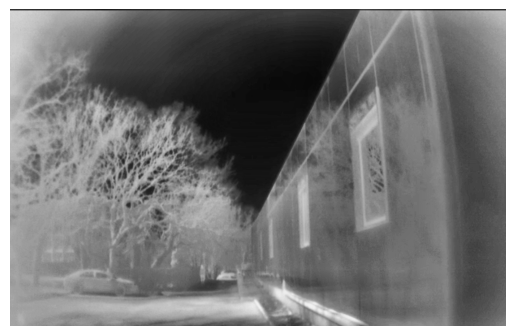

In [17]:
# CLAHE (Contrast Limited Adaptive Histogram Equalization)
# clipLimit    → limits how strong the contrast enhancement is
# tileGridSize → size of local regions
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

clahe_img = clahe.apply(gray_image)

cv2.imwrite(save_path + "clahe.jpg", clahe_img)

print("CLAHE")
plt.imshow(clahe_img, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()




In [19]:
# Testing variations
settings = [
    (1.0, (8, 8)),
    (2.0, (8, 8)),
    (4.0, (8, 8)),
    (2.0, (4, 4)),
    (2.0, (16, 16)),
]

for clip, tile in settings:
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=tile)
    result = clahe.apply(gray_image)
    filename = save_path + f"clahe_clip{clip}_tile{tile[0]}x{tile[1]}.jpg"
    cv2.imwrite(filename, result)

Original image


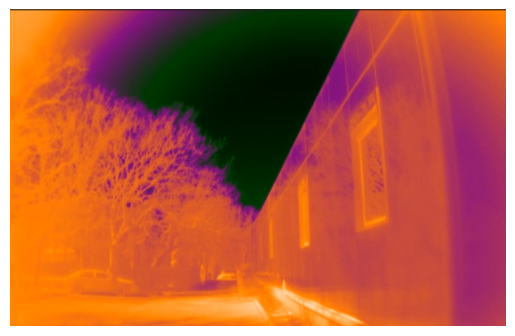

CLAHE to color image


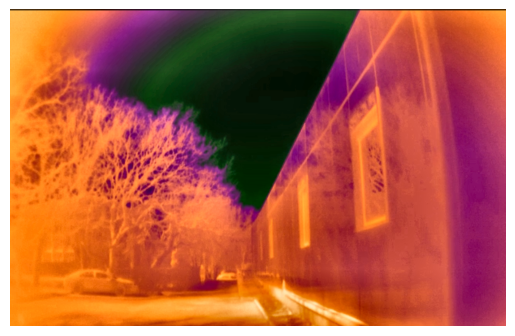

In [21]:
# Apply CLAHE to color images correctly
# Do not usually apply histogram equalization independently to B, G, and R channels. It can distort colors.

lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
l_clahe = clahe.apply(l)

lab_clahe = cv2.merge((l_clahe, a, b))
color_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)

cv2.imwrite(save_path + "color_clahe_lab.jpg", color_clahe)

print("Original image")
plt.imshow(_convert_from_bgr_to_rgb(img), vmin=0, vmax=255)
plt.axis("off")
plt.show()

print("CLAHE to color image")
plt.imshow(_convert_from_bgr_to_rgb(color_clahe), vmin=0, vmax=255)
plt.axis("off")
plt.show()